In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df=pd.read_csv("ushape.csv",header=None)
df.columns=['x','y','result']
df.head(5)

,x,y,result
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


In [13]:
x=df.iloc[:,0:2].values
y=df.iloc[:,-1].values

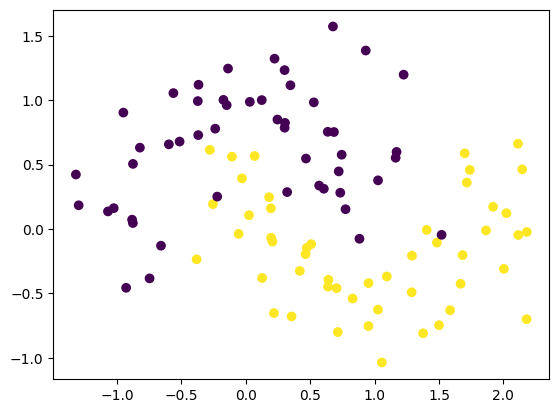

In [15]:
plt.scatter(x[:,0],x[:,1],c=y)

In [16]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()

In [17]:
clf.fit(x,y)

LogisticRegression()

<Axes: >

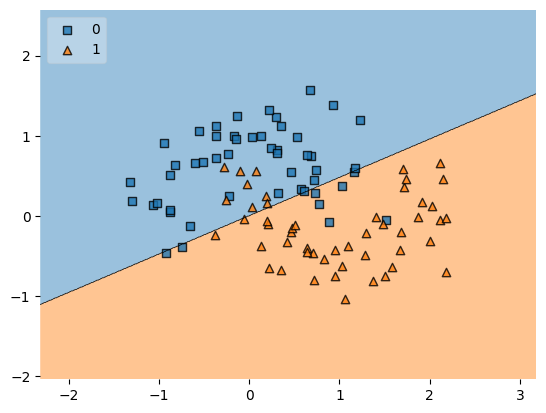

In [20]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x,y.astype('int'),clf,legend=2)

In [21]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(clf,x,y,scoring='accuracy',cv=10))

0.8300000000000001

In [22]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3,include_bias=False)
x_trf=poly.fit_transform(x)

In [23]:
clf1=LogisticRegression()
np.mean(cross_val_score(clf1,x_trf,y,scoring='accuracy',cv=10))

0.9

In [50]:
a=np.arange(start=x[:,0].min()-1,stop=x[:,0].max()+1,step=0.01)
b=np.arange(start=x[:,1].min()-1,stop=x[:,1].max()+1,step=0.01)
    
xx,yy=np.meshgrid(a,b)
xx,yy

(array([[-2.31850034, -2.30850034, -2.29850034, ...,  3.15149966,
          3.16149966,  3.17149966],
        [-2.31850034, -2.30850034, -2.29850034, ...,  3.15149966,
          3.16149966,  3.17149966],
        [-2.31850034, -2.30850034, -2.29850034, ...,  3.15149966,
          3.16149966,  3.17149966],
        ...,
        [-2.31850034, -2.30850034, -2.29850034, ...,  3.15149966,
          3.16149966,  3.17149966],
        [-2.31850034, -2.30850034, -2.29850034, ...,  3.15149966,
          3.16149966,  3.17149966],
        [-2.31850034, -2.30850034, -2.29850034, ...,  3.15149966,
          3.16149966,  3.17149966]]),
 array([[-2.03570207, -2.03570207, -2.03570207, ..., -2.03570207,
         -2.03570207, -2.03570207],
        [-2.02570207, -2.02570207, -2.02570207, ..., -2.02570207,
         -2.02570207, -2.02570207],
        [-2.01570207, -2.01570207, -2.01570207, ..., -2.01570207,
         -2.01570207, -2.01570207],
        ...,
        [ 2.54429793,  2.54429793,  2.54429793, ...,  

In [33]:
def plot_decision_boundary(x,y,degree=1):
    
    poly=PolynomialFeatures(degree=degree)
    x_trf=poly.fit_transform(x)
    
    clf=LogisticRegression()
    clf.fit(x_trf,y)
    
    accuracy=np.mean(cross_val_score(clf,x,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=x[:,0].min()-1,stop=x[:,0].max()+1,step=0.01)
    b=np.arange(start=x[:,1].min()-1,stop=x[:,1].max()+1,step=0.01)
    
    xx,yy=np.meshgrid(a,b)
    
    input_array=np.array([xx.ravel(),yy.ravel()]).T
    
    labels=clf.predict(poly.transform(input_array))
    
    plt.contour(xx,yy,labels.reshape(xx.shape),alpha=0.5)
    plt.scatter(x[:,0],x[:,1],c=y)
    plt.title('Degree={},accuracy is {}'.format(degree,np.round(accuracy,4)))

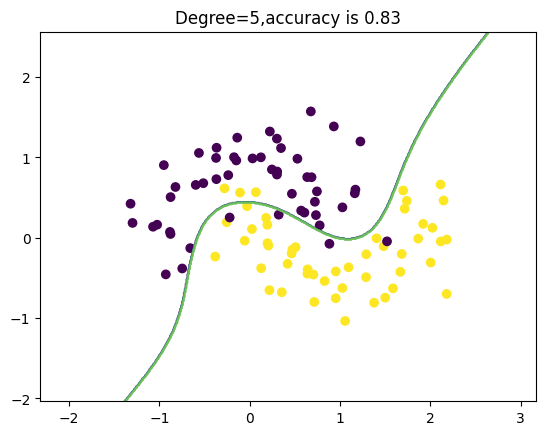

In [43]:
plot_decision_boundary(x,y,5)